In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision diffusers accelerate
!pip install matplotlib pillow

In [ ]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
train_dataset = ImageFolder(
    root="/content/drive/MyDrive/trafficDataset/train",
    transform=transform
)

In [ ]:
print(train_dataset.class_to_idx)

{'fog': 0, 'night': 1, 'rain': 2}


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

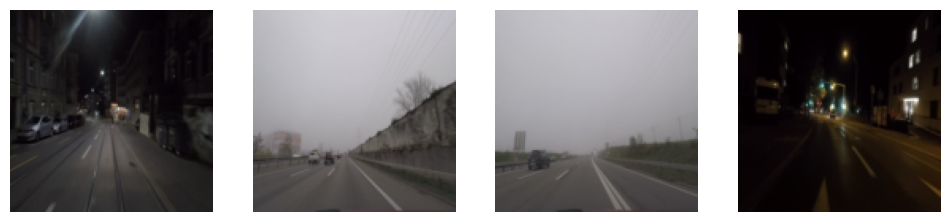

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i in range(4):
    img = images[i].permute(1,2,0)
    img = (img * 0.5) + 0.5

    axes[i].imshow(img)
    axes[i].axis("off")

plt.show()

latent diffusion framework

In [ ]:
from diffusers import DDPMScheduler, UNet2DModel

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)

In [ ]:
model = UNet2DModel(
    sample_size=128,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

print("Using device:", device)

Using device: cuda


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)

noise = torch.randn_like(images)

timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (images.shape[0],),
    device=device
).long()

noisy_images = noise_scheduler.add_noise(
    images,
    noise,
    timesteps
)

output = model(noisy_images, timesteps).sample

print(output.shape)

torch.Size([8, 3, 128, 128])


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

In [ ]:
from tqdm.auto import tqdm
import torch.nn.functional as F

num_epochs = 30

losses = []

for epoch in range(num_epochs):

    progress_bar = tqdm(train_loader)

    for step, (images, labels) in enumerate(progress_bar):

        images = images.to(device)

        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        progress_bar.set_description(
            f"Epoch {epoch}"
        )

        progress_bar.set_postfix(
            loss=loss.item()
        )

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

...

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

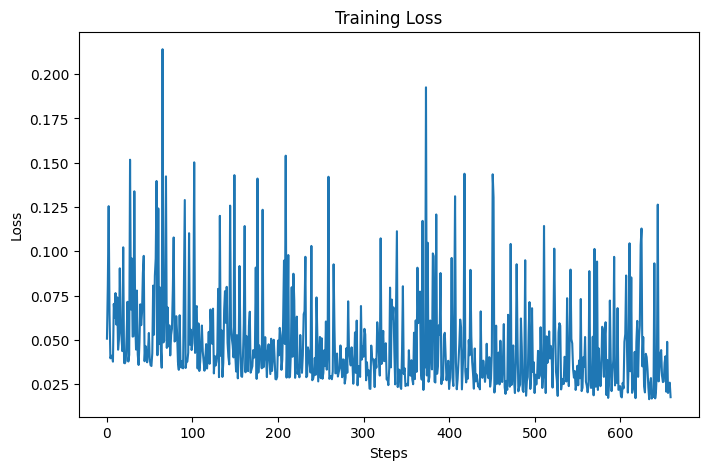

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Steps")

plt.ylabel("Loss")

plt.show()

**IMAGE** **GENERATION**

In [ ]:
model.eval()

UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

In [ ]:
sample = torch.randn(
    (1, 3, 128, 128)
).to(device)

In [ ]:
from tqdm.auto import tqdm

for t in tqdm(range(999, -1, -1)):

    timestep = torch.tensor([t]).to(device)

    with torch.no_grad():

        residual = model(
            sample,
            timestep
        ).sample

    sample = noise_scheduler.step(
        residual,
        timestep,
        sample
    ).prev_sample

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
image = sample[0].detach().cpu()

image = image.permute(1,2,0).numpy()

image = (image + 2) / 2

image = image.clip(0,1)

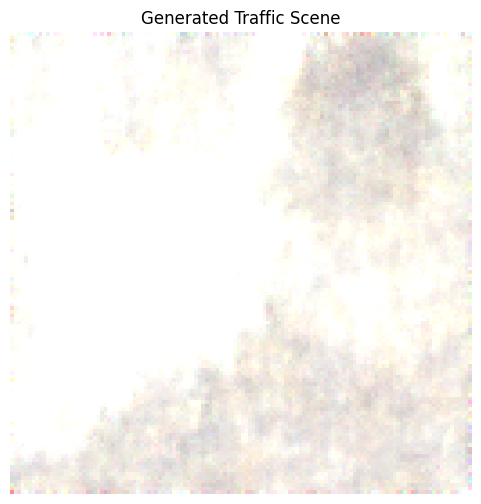

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title("Generated Traffic Scene")

plt.axis("off")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "traffic_diffusion_model.pth"
)

In [ ]:
import torch.nn as nn

label_embedding = nn.Embedding(
    num_embeddings=3,
    embedding_dim=128
).to(device)

In [ ]:
model.eval()

UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

In [ ]:
weather_label = torch.tensor([2]).to(device)
condition = label_embedding(weather_label)

condition = condition.view(
    1,
    128,
    1,
    1
)

condition = condition.expand(
    -1,
    -1,
    128,
    128
)

In [ ]:
sample = torch.randn(
    (1, 3, 128, 128)
).to(device)



In [ ]:
from tqdm.auto import tqdm

for t in tqdm(range(999, -1, -1)):

    timestep = torch.tensor([t]).to(device)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
conditioned_input = torch.cat(
        [sample, condition[:, :3]],
        dim=1
    )

In [ ]:
model = UNet2DModel(

    sample_size=128,

    in_channels=6,

    out_channels=3,

    layers_per_block=2,

    block_out_channels=(64, 128, 128),

    down_block_types=(

        "DownBlock2D",

        "AttnDownBlock2D",

        "AttnDownBlock2D",

    ),

    up_block_types=(

        "AttnUpBlock2D",

        "AttnUpBlock2D",

        "UpBlock2D",

    ),

).to(device)

In [ ]:
with torch.no_grad():

        residual = model(
            conditioned_input,
            timestep
        ).sample

In [ ]:
 sample = noise_scheduler.step(
        residual,
        timestep,
        sample
    ).prev_sample

In [ ]:
image = sample[0].detach().cpu()

image = image.permute(1,2,0).numpy()

image = (image + 1) / 2

image = image.clip(0,1)

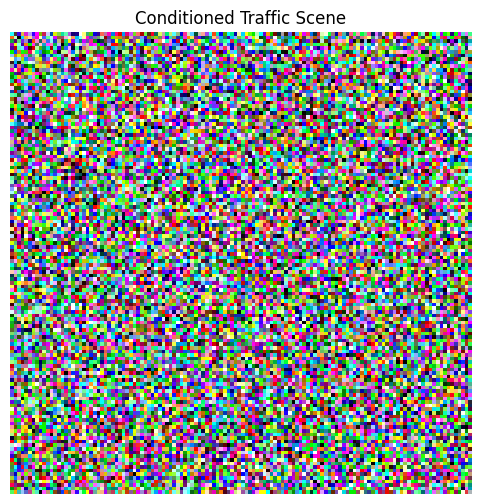

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title("Conditioned Traffic Scene")

plt.axis("off")

plt.show()

In [ ]:
plt.imsave(
    "/content/drive/MyDrive/conditioned_traffic_scene.png",
    image
)

print("Conditioned Image Saved Successfully")

Conditioned Image Saved Successfully


STABLE DIFFUSION TRAFFIC GENERATION


In [2]:
!pip install diffusers transformers accelerate safetensors
!pip install torch torchvision
!pip install matplotlib pillow

In [3]:
import torch
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
prompt = """
ultra realistic rainy urban traffic road,
cars on wet highway,
heavy rain,
cinematic lighting,
night city reflections,
realistic vehicles,
highly detailed traffic scene,
professional photography,
8k,
realistic weather effects
"""

image = pipe(
    prompt,
    num_inference_steps=100,
    guidance_scale=10
).images[0]

  0%|          | 0/100 [00:00<?, ?it/s]

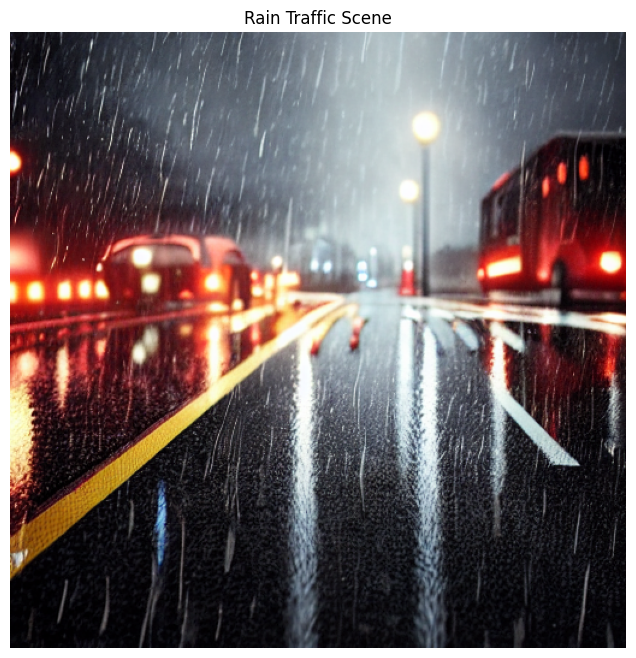

In [14]:
plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

plt.title("Rain Traffic Scene")

plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

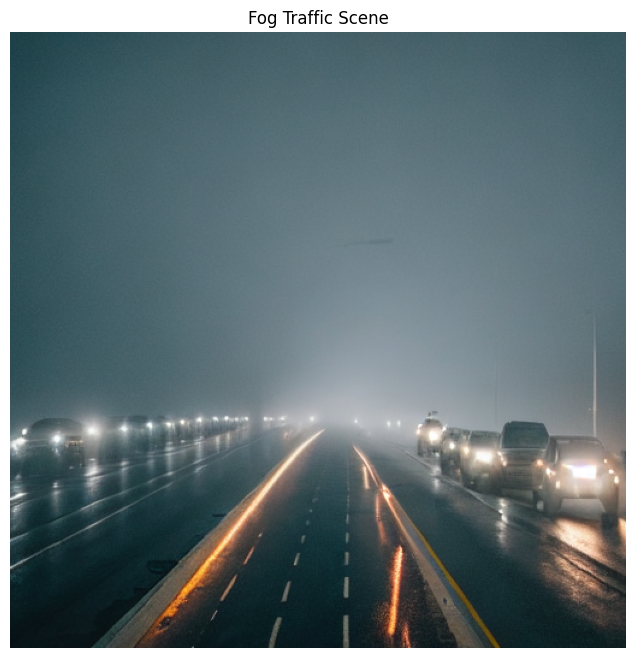

In [16]:
prompt = """
ultra realistic foggy traffic highway,
dense fog on urban road,
cars driving through fog,
low visibility weather,
cinematic atmosphere,
realistic vehicles,
wet asphalt,
professional traffic photography,
moody lighting,
highly detailed,
8k realistic traffic scene
"""

negative_prompt = """
blurry,
low quality,
cartoon,
anime,
distorted vehicles,
painting,
oversaturated,
unrealistic
"""

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=100,
    guidance_scale=10
).images[0]

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Fog Traffic Scene")
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

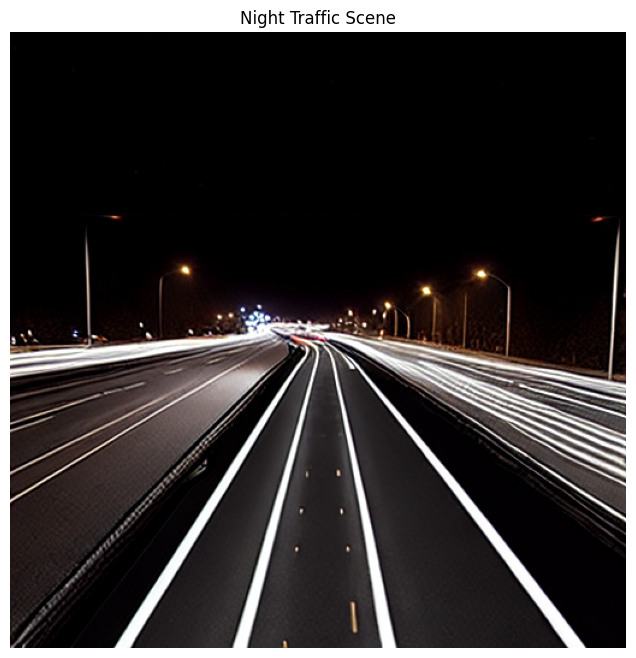

In [25]:
prompt = """
ultra realistic midnight traffic highway,
deep black sky,
very dark road,
cars with only headlights visible,
minimal street lighting,
low exposure photography,
realistic nighttime driving,
dark cinematic atmosphere,
wet asphalt reflections,
highly detailed realistic vehicles,
professional night traffic photography,
8k
"""

negative_prompt = """
daylight,
sunlight,
bright sky,
morning,
afternoon,
bright environment,
cartoon,
anime,
painting,
oversaturated,
low quality,
unrealistic,
blurry
"""

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=200,
    guidance_scale=20
).images[0]

plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

plt.title("Night Traffic Scene")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/traffic_diffusion_model.pth"
)

print("Model Saved")